In [12]:
# Импорты
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Настройки
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
NUM_CLASSES = 10  # EuroSAT имеет 10 классов
DATA_DIR = "./data"

print(f"Устройство: {DEVICE}")

Устройство: cuda


In [3]:
# Разбитие данных из датасета
import shutil
from sklearn.model_selection import train_test_split
raw_dir = "./euroSAT"
for cls in os.listdir(raw_dir):
    cls_path = os.path.join(raw_dir, cls)
    if not os.path.isdir(cls_path): continue
    imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
    train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)
    for src, dst_dir in [(train_imgs, "train"), (val_imgs, "val")]:
        dst_cls = os.path.join(DATA_DIR, dst_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)
        for f in src: shutil.copy(f, dst_cls)

In [3]:
# Трансформации и загрузка данных
# Аугментации для обучения
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Преобразования для валидации/теста
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка через ImageFolder (ожидает структуру: DATA_DIR/train/<класс>/img.jpg)
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)

# DataLoader'ы (num_workers=2 для Linux/Mac/Colab, на Windows поставь 0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f" Train: {len(train_dataset)} изображений | Val: {len(val_dataset)} изображений")
print(f" Классы: {train_dataset.classes}")

 Train: 21600 изображений | Val: 5400 изображений
 Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [4]:
# Модель ResNet18 и стратегия Fine-tuning
# Загружаем предобученную на ImageNet модель
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Fine-tuning: замораживаем ранние слои, обучаем последний блок + классификатор
for name, param in model.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

# Заменяем выходной слой под 10 классов
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

print("Модель загружена и подготовлена к fine-tuning")

Модель загружена и подготовлена к fine-tuning


In [5]:
# Критерий, оптимизатор и расписание LR
criterion = nn.CrossEntropyLoss()

# Оптимизатор учит только те параметры, у которых requires_grad=True
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

# Уменьшаем LR, если валидационный лосс не падает
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [7]:
# Функции обучения и валидации
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += labels.size(0)
    return running_loss / total, correct.double() / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
    return running_loss / total, correct.double() / total

In [13]:
# Цикл обучения
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc = validate_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(v_loss)  # Адаптация LR

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc); val_accs.append(v_acc)

    print(f"Train Loss: {t_loss:.4f} | Acc: {t_acc:.4f}")
    print(f"Val   Loss: {v_loss:.4f} | Acc: {v_acc:.4f}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        os.makedirs("models", exist_ok=True)
        torch.save(model.state_dict(), "models/resnet18_eurosat_best.pth")
        print("Saved best model!")


Epoch 1/25 | LR: 0.001000


Train Loss: 0.2149 | Acc: 0.9297
Val   Loss: 0.0824 | Acc: 0.9728
Saved best model!

Epoch 2/25 | LR: 0.001000


Train Loss: 0.2094 | Acc: 0.9329
Val   Loss: 0.1180 | Acc: 0.9587

Epoch 3/25 | LR: 0.001000


Train Loss: 0.1971 | Acc: 0.9355
Val   Loss: 0.0857 | Acc: 0.9720

Epoch 4/25 | LR: 0.001000


Train Loss: 0.1978 | Acc: 0.9336
Val   Loss: 0.1048 | Acc: 0.9683

Epoch 5/25 | LR: 0.000500


...

Train Loss: 0.1182 | Acc: 0.9607
Val   Loss: 0.0643 | Acc: 0.9796

Epoch 22/25 | LR: 0.000125


Train Loss: 0.1131 | Acc: 0.9627
Val   Loss: 0.0679 | Acc: 0.9791

Epoch 23/25 | LR: 0.000063


Train Loss: 0.1108 | Acc: 0.9642
Val   Loss: 0.0655 | Acc: 0.9774

Epoch 24/25 | LR: 0.000063


Train Loss: 0.1102 | Acc: 0.9643
Val   Loss: 0.0618 | Acc: 0.9794

Epoch 25/25 | LR: 0.000063


Train Loss: 0.1109 | Acc: 0.9634
Val   Loss: 0.0648 | Acc: 0.9785


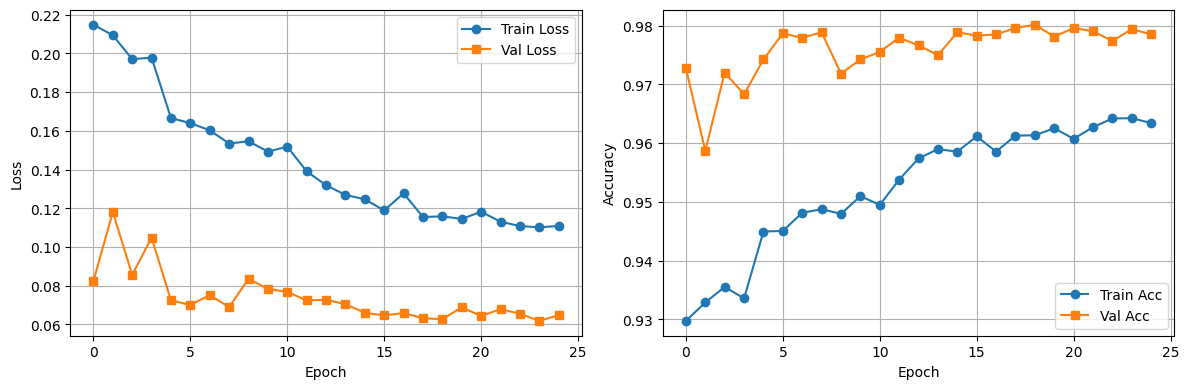

In [21]:
import matplotlib.pyplot as plt

# 1. УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ОЧИСТКИ
# Она превратит тензоры GPU в числа, а обычные числа оставит как есть.
# Это исправит обе ошибки сразу.
def to_float_list(data_list):
    return [x.item() if hasattr(x, 'item') else x for x in data_list]

# Преобразуем списки перед отрисовкой
clean_train_losses = to_float_list(train_losses)
clean_val_losses = to_float_list(val_losses)
clean_train_accs = to_float_list(train_accs)
clean_val_accs = to_float_list(val_accs)

# 2. ОТРИСОВКА
plt.figure(figsize=(12, 4))

# График потерь (Loss)
plt.subplot(1, 2, 1)
plt.plot(clean_train_losses, label="Train Loss", marker='o')
plt.plot(clean_val_losses, label="Val Loss", marker='s')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)

# График точности (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(clean_train_accs, label="Train Acc", marker='o')
plt.plot(clean_val_accs, label="Val Acc", marker='s')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import os

# ==========================================
# 1. НАСТРОЙКИ ТЕСТА
# ==========================================
MODEL_NAME = 'resnet18'           # Имя модели для теста
CHECKPOINT_PATH = 'models/resnet18_eurosat_best.pth'  # Путь к сохраненным весам
DATA_DIR = "data/train"         # Путь к обучащему датасету
BATCH_SIZE = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 10

# ==========================================
# 2. ТРАНСФОРМАЦИИ (ВАЖНО: Должны совпадать с обучением!)
# ==========================================
# Мы используем те же параметры нормализации, на которых модель училась.
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # Эти mean и std стандартные для ImageNet, на которых предобучен ResNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 3. ЗАГРУЗКА МОДЕЛИ
# ==========================================
def get_model(name, num_classes):
    if name == 'resnet18':
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == 'resnet34':
        model = models.resnet34(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError("Модель не поддерживается в этом тесте")
    return model

print(f"Тестируем модель: {MODEL_NAME}")

model = get_model(MODEL_NAME, NUM_CLASSES)

# Загрузка весов
if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    print(f"Веса загружены из: {CHECKPOINT_PATH}")
else:
    print(f"Файл весов не найден: {CHECKPOINT_PATH}. Используются случайные веса.")

model = model.to(DEVICE)
model.eval()

# ==========================================
# 4. ЗАПУСК ПРОВЕРКИ
# ==========================================
try:
    # Загружаем датасет с правильными трансформациями
    test_dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Загружено {len(test_dataset)} изображений для проверки.")

    if len(test_loader) == 0:
        print("Данные пусты. Проверьте правильность пути DATA_DIR.")
    else:
        criterion = nn.CrossEntropyLoss()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)

                _, preds = torch.max(outputs, 1)
                correct += torch.sum(preds == labels.data)
                total += labels.size(0)

        avg_loss = running_loss / total
        accuracy = correct.double() / total

        print(f"Точность (Accuracy): {accuracy*100:.2f}%")
        print(f"Ошибка (Loss): {avg_loss:.4f}")

        if accuracy < 0.20:
            print("Внимание: Точность очень низкая.")

except Exception as e:
    print(f"Произошла ошибка: {e}")
    print("Проверьте, существует ли папка data/eurosat и есть ли в ней подпапки с классами.")

Тестируем модель: resnet18
Веса загружены из: models/resnet18_eurosat_best.pth
Загружено 21600 изображений для проверки.
Точность (Accuracy): 99.55%
Ошибка (Loss): 0.0152
